<a href="https://colab.research.google.com/github/WVF-1/Bike-Lane-Analysis/blob/main/Pittsburgh_bike_network_geospatial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geospatial 101, Part 1: Mapping Pittsburgh's Bike Network

**Newsletter series: Geospatial Data & Public Transportation**

This is week 1 of a four-part series. Our end goal (week 4) is a graph neural network that helps coordinate streetlights at intersections. To get there, we need to get comfortable with a core idea: **city streets are naturally a graph** — intersections are *nodes*, street segments are *edges*. Everything from here forward builds on that idea.

This notebook is your "Geospatial 101" — we'll cover:
1. What geospatial (vector) data actually is, and why coordinate reference systems (CRS) matter
2. Pulling a real, live street network for Pittsburgh, PA — no manual downloads
3. Identifying which streets have bike infrastructure
4. Visualizing the network
5. Saving our data to CSV so we can pick it up again in Notebook 2

**Data source:** [OpenStreetMap](https://www.openstreetmap.org/), pulled programmatically via the `osmnx` Python library (Overpass API under the hood). OSM data is released under the [Open Database License (ODbL)](https://opendatacommons.org/licenses/odbl/) — free to use and build on, with attribution required if you redistribute the raw data itself.

## Setup

Install the two packages we need. `osmnx` handles pulling and working with street networks; it depends on `geopandas` for the underlying spatial dataframes.

In [1]:
!pip install osmnx geopandas -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.5 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

ox.settings.log_console = False
print("osmnx version:", ox.__version__)


osmnx version: 2.1.0


## A quick word on geospatial data

Most of the data you've probably worked with before is *tabular* — rows and columns, no inherent sense of "where." Geospatial data adds a **geometry** column: every row is tied to a point, line, or polygon on the Earth's surface.

Two things trip people up the first time:

- **Coordinates aren't just numbers.** A latitude/longitude pair only means something in the context of a **Coordinate Reference System (CRS)**. The default for most web data (including OSM) is `EPSG:4326` — plain lat/lon in degrees, sometimes called WGS84.
- **Degrees aren't distance.** You can't accurately compute lengths or areas in degrees — a degree of longitude covers a different real-world distance depending on how far you are from the equator. For real measurements, we *project* the data into a CRS measured in meters (here, we'll use a UTM zone appropriate for Pittsburgh).

We'll see both of these in action below.

## Pulling Pittsburgh's street network

We ask OSM for everything a bicyclist could route on within the city boundary. This single function call replaces what would otherwise be a manual shapefile download.

In [3]:
place = "Pittsburgh, Pennsylvania, USA"

# network_type="bike" returns the subset of streets/paths that are
# rideable by bicycle -- this includes dedicated cycleways *and*
# ordinary streets (which may or may not have a painted bike lane).
G = ox.graph_from_place(place, network_type="bike")

print(f"Nodes (intersections/endpoints): {len(G.nodes):,}")
print(f"Edges (street segments):         {len(G.edges):,}")


Nodes (intersections/endpoints): 23,315
Edges (street segments):         59,800


## Nodes and edges

This is the moment to sit with the structure we just pulled:

- **Every node is an intersection** (or a dead end / the edge of our search area).
- **Every edge is a street segment** connecting two nodes.

This is *exactly* the representation we'll need in Week 3 for the traffic-light simulation, and in Week 4 for the GNN. We're not building anything new later — we're going to keep coming back to this same idea.

In [4]:
# Reproject to a metric CRS (UTM zone 17N covers Pittsburgh) so that
# distance calculations below are in real meters, not degrees.
G_proj = ox.project_graph(G)

# Convert the graph into two GeoDataFrames -- this is the tabular,
# geospatial-native format we'll actually work with and export.
nodes, edges = ox.graph_to_gdfs(G_proj)

print("Nodes columns:", list(nodes.columns))
print("Edges columns:", list(edges.columns))
edges.head()


Nodes columns: ['y', 'x', 'street_count', 'highway', 'junction', 'ref', 'railway', 'geometry']
Edges columns: ['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length', 'maxspeed', 'service', 'geometry', 'access', 'bridge', 'tunnel', 'ref', 'width', 'est_width', 'junction']


osmid      highway lanes              name  \
u         v         key                                                   
104185739 104185746 0     11651757  residential     2  Ainsworth Street   
          104678799 0    294921171  residential     2     Lorenz Avenue   
          105697570 0    294921171  residential     2     Lorenz Avenue   
104185746 104185749 0     11651757  residential     2  Ainsworth Street   
          104185739 0     11651757  residential     2  Ainsworth Street   

                         oneway reversed     length maxspeed service  \
u         v         key                                                
104185739 104185746 0     False    False  39.383096      NaN     NaN   
          104678799 0     False    False  39.073503   25 mph     NaN   
          105697570 0     False     True  40.680692   25 mph     NaN   
104185746 104185749 0     False    False  82.869453      NaN     NaN   
          104185739 0     False     True  39.383096      NaN     NaN   

                                                                  geometry  \
u         v         key                                                      
104185739 104185746 0    LINESTRING (581419.888 4477532.948, 581446.505...   
          104678799 0    LINESTRING (581419.888 4477532.948, 581390.688...   
          105697570 0    LINESTRING (581419.888 4477532.948, 581450.28 ...   
104185746 104185749 0    LINESTRING (581446.505 4477503.918, 581501.991...   
          104185739 0    LINESTRING (581446.505 4477503.918, 581419.888...   

                        access bridge tunnel  ref width est_width junction  
u         v         key                                                     
104185739 104185746 0      NaN    NaN    NaN  NaN   NaN       NaN      NaN  
          104678799 0      NaN    NaN    NaN  NaN   NaN       NaN      NaN  
          105697570 0      NaN    NaN    NaN  NaN   NaN       NaN      NaN  
104185746 104185749 0      NaN    NaN    NaN  NaN   NaN       NaN      NaN  
          104185739 0      NaN    NaN    NaN  NaN   NaN       NaN      NaN

## Finding the bike infrastructure

OSM tags bike infrastructure two main ways:
- `highway == "cycleway"` → a dedicated, physically separate bike path
- a `cycleway` tag (e.g. `cycleway=lane`, `cycleway=track`) on an ordinary street → a painted/marked lane sharing the street with cars

We'll flag both as `has_bike_infra`.

In [5]:
def flag_bike_infra(row):
    if row.get("highway") == "cycleway":
        return True
    cw = row.get("cycleway")
    if isinstance(cw, list):
        return any(pd.notna(c) and c != "no" for c in cw)
    return pd.notna(cw) and cw != "no"

edges["has_bike_infra"] = edges.apply(flag_bike_infra, axis=1)

total_length_mi = edges["length"].sum() / 1609.34
bike_length_mi = edges.loc[edges["has_bike_infra"], "length"].sum() / 1609.34

print(f"Total network length:        {total_length_mi:,.1f} miles")
print(f"Length with bike infra:      {bike_length_mi:,.1f} miles")
print(f"Share of network with infra: {bike_length_mi/total_length_mi:.1%}")
print(f"Edges with bike infra:       {edges['has_bike_infra'].sum():,} of {len(edges):,}")


Total network length:        2,942.2 miles
Length with bike infra:      83.6 miles
Share of network with infra: 2.8%
Edges with bike infra:       1,166 of 59,800


## Visualizing the network

Gray = general street network. Highlighted = streets with bike infrastructure.

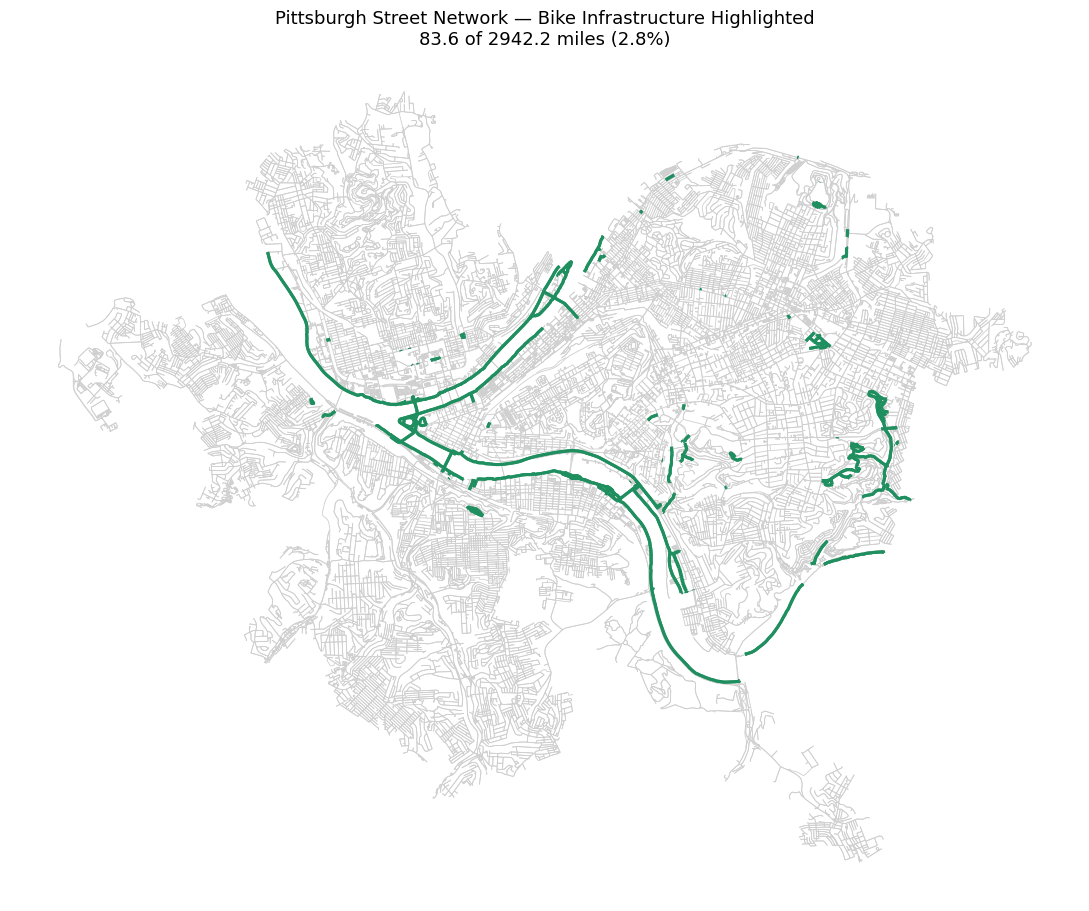

In [6]:
fig, ax = plt.subplots(figsize=(11, 11))

edges.plot(ax=ax, color="#cfcfcf", linewidth=0.6, zorder=1)
edges[edges["has_bike_infra"]].plot(ax=ax, color="#1f8f5f", linewidth=2.2, zorder=2)

ax.set_title(f"Pittsburgh Street Network — Bike Infrastructure Highlighted\n{bike_length_mi:.1f} of {total_length_mi:.1f} miles ({bike_length_mi/total_length_mi:.1%})",
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("pittsburgh_bike_network_map.png", dpi=150)
plt.show()


## A local detail: bridges

Pittsburgh has [more bridges than almost any city in the world](https://en.wikipedia.org/wiki/List_of_bridges_in_Pittsburgh). Since bridges are often chokepoints for bike/pedestrian crossings, let's pull them out specifically — this is also a nice preview of the "bridge or two" you mentioned wanting in the week 3 simulation.

In [7]:
def is_bridge(row):
    b = row.get("bridge")
    if isinstance(b, list):
        return any(pd.notna(x) and x != "no" for x in b)
    return pd.notna(b) and b != "no"

edges["is_bridge"] = edges.apply(is_bridge, axis=1)
bridge_edges = edges[edges["is_bridge"]]

print(f"Bridge segments found: {len(bridge_edges)}")
bridge_edges[["name", "has_bike_infra", "length"]].dropna(subset=["name"]).drop_duplicates(subset=["name"]).head(15)


Bridge segments found: 449


,,,name,has_bike_infra,length
u,v,key,,,
104187288,2515581363,0,Davis Avenue Bridge,False,155.936411
104191311,684907625,0,East Ohio Street,False,88.330480
270927856,3598883405,0,Schenley Drive,False,202.124394
3161770014,10131810954,1,"[Turkey Run Trail, Emerald View Trail]",False,681.721557
8256990317,686151965,0,Milroy Street,False,281.768879
1253610159,104871606,0,"[30th Street Bridge, 30th Street]",False,141.527327
1790005701,104383287,0,Centre Avenue,False,94.373400
105259037,104568322,0,Lowrie Street,False,133.179701
104449098,684597808,0,McKees Rocks Bridge,False,50.614747


## Exporting for Notebook 2

Geometry columns don't survive a plain CSV round-trip, so we convert each geometry to **WKT (Well-Known Text)** — a standard string representation we can parse right back into a geometry next time.

We're exporting two files:
- `pittsburgh_bike_network_edges.csv` — the street segments, with bike-infra flags and geometry
- `pittsburgh_bike_network_nodes.csv` — the intersections, with lat/lon coordinates

Keep both — you'll upload them at the start of Notebook 2.

In [9]:
# --- Edges: keep the projected geometry (meters) as WKT for accurate
# length-based analysis, plus a WGS84 (lat/lon) version for mapping/joins.
edges_export = edges.copy()
edges_export["geometry_utm_wkt"] = edges_export.geometry.apply(lambda g: g.wkt)

edges_ll = ox.graph_to_gdfs(G, nodes=False, edges=True)  # unprojected version
edges_export["geometry_wgs84_wkt"] = edges_ll.geometry.apply(lambda g: g.wkt)

edges_export = edges_export.reset_index()  # brings back u, v, key as columns
keep_cols = ["u", "v", "key", "osmid", "name", "highway", "cycleway",
             "bridge", "length", "has_bike_infra", "is_bridge",
             "geometry_utm_wkt", "geometry_wgs84_wkt"]
keep_cols = [c for c in keep_cols if c in edges_export.columns]
edges_export = edges_export[keep_cols]

# Lists (multi-tagged OSM ways) don't play nicely with CSV -- stringify them.
for c in edges_export.columns:
    edges_export[c] = edges_export[c].apply(lambda v: str(v) if isinstance(v, list) else v)

edges_export.to_csv("pittsburgh_bike_network_edges.csv", index=False)
print(f"Saved pittsburgh_bike_network_edges.csv -- {len(edges_export):,} rows")

Saved pittsburgh_bike_network_edges.csv -- 59,800 rows


In [10]:
# --- Nodes: lat/lon (WGS84) is what we'll need for the Census tract
# spatial join in Notebook 2, so pull coordinates from the unprojected graph.
nodes_ll, _ = ox.graph_to_gdfs(G, nodes=True, edges=True)
nodes_export = nodes_ll.reset_index()[["osmid", "y", "x", "street_count"]].copy()
nodes_export = nodes_export.rename(columns={"y": "lat", "x": "lon"})

nodes_export.to_csv("pittsburgh_bike_network_nodes.csv", index=False)
print(f"Saved pittsburgh_bike_network_nodes.csv -- {len(nodes_export):,} rows")


Saved pittsburgh_bike_network_nodes.csv -- 23,315 rows


## Download your files

Running in Colab, this will pop a browser download for both CSVs. Save them somewhere you can find them — you'll upload them at the top of Notebook 2.

In [11]:
from google.colab import files

files.download("pittsburgh_bike_network_edges.csv")
files.download("pittsburgh_bike_network_nodes.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap + what's next

You just:
- Pulled a real, current street network for Pittsburgh with one function call (no manual downloads, no license agreements to click through)
- Learned why CRS/projection matters for real distance calculations
- Represented the city as a graph — nodes (intersections) and edges (street segments) — the same structure we'll reuse in weeks 3–4
- Identified and mapped bike infrastructure, and pulled out bridge crossings
- Exported everything to CSV for the next notebook

**Notebook 2** picks up here: we'll bring in Census data on where Pittsburghers actually commute by bike, and see how that lines up with where the infrastructure is.